# **Project UAS Kecerdasan Buatan**

## **Library**

In [115]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns
import pyswarms as ps
import time
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import ADASYN
from typing import Dict, List, Tuple, Any
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

## **Data**

In [116]:
data = pd.read_csv('adult.csv')
data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## **EDA**

In [117]:
data[data == '?'] = np.nan
data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [118]:
data.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

In [119]:
X = data.drop('income', axis=1)
y = data['income']

### **Data Distribution**

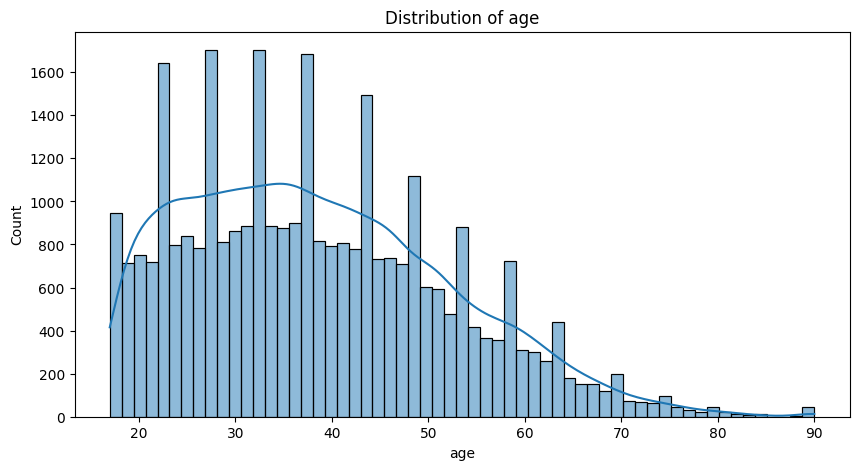

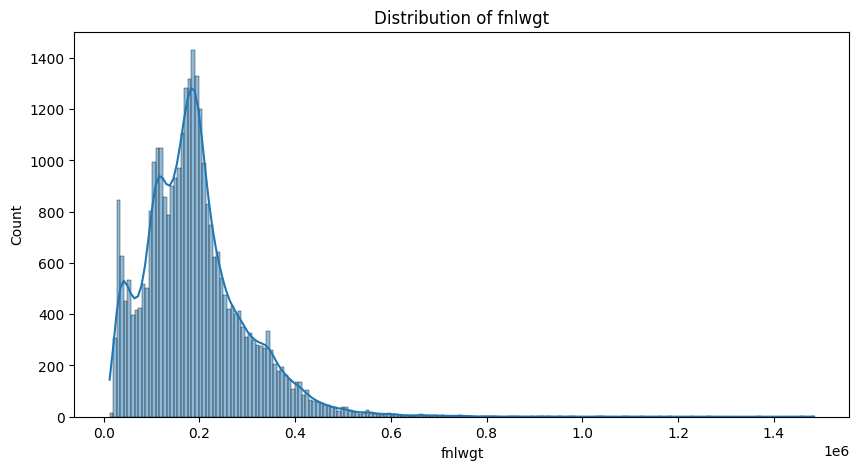

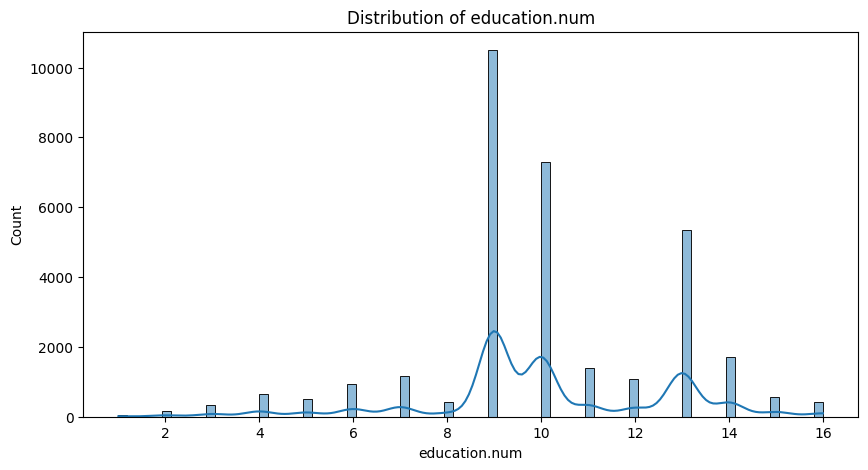

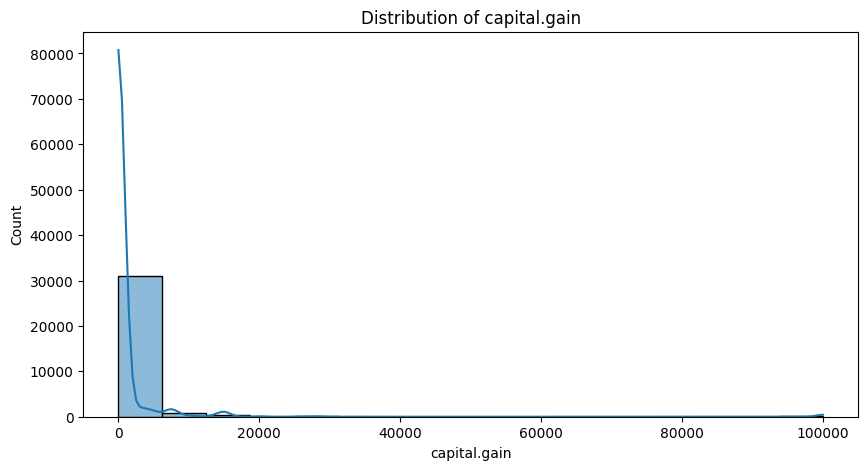

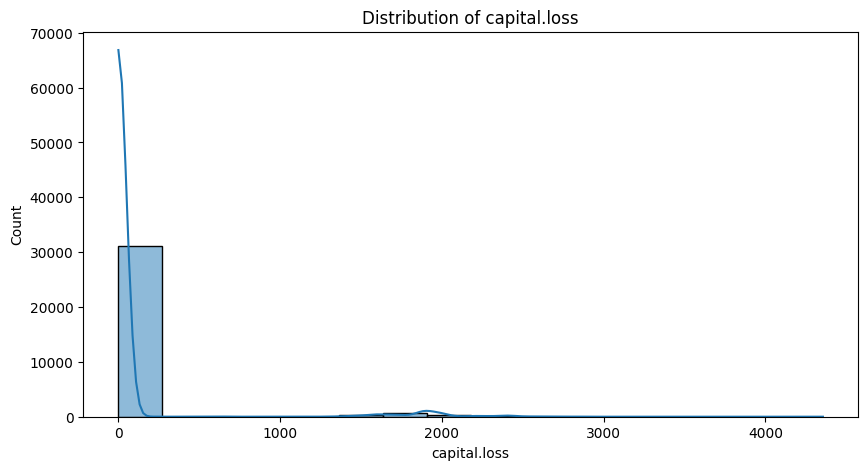

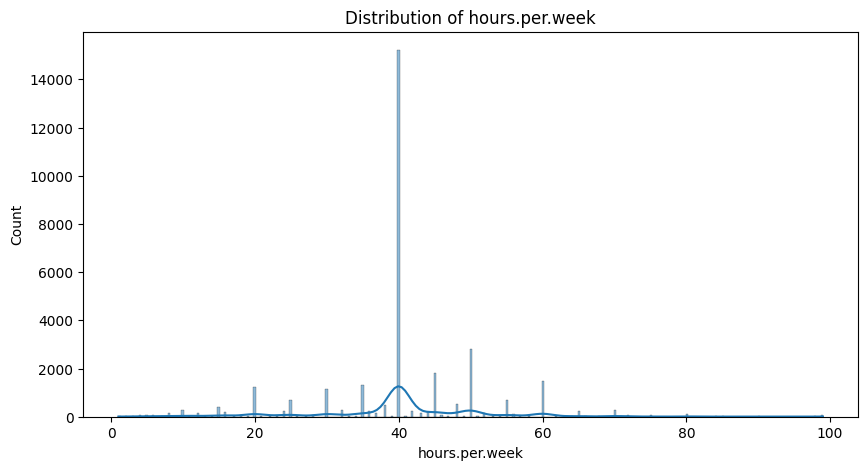

In [120]:
num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

for i in num_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(X[i], kde=True)
    plt.title(f'Distribution of {i}')
    plt.show()

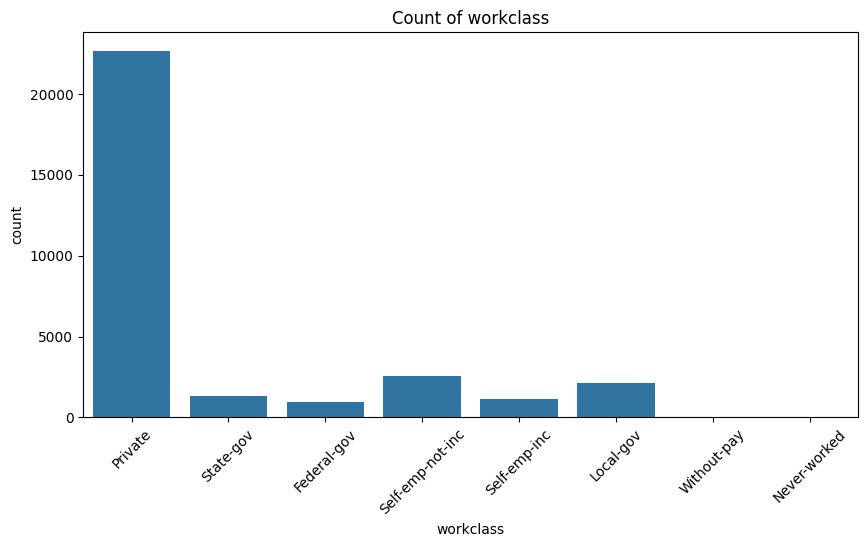

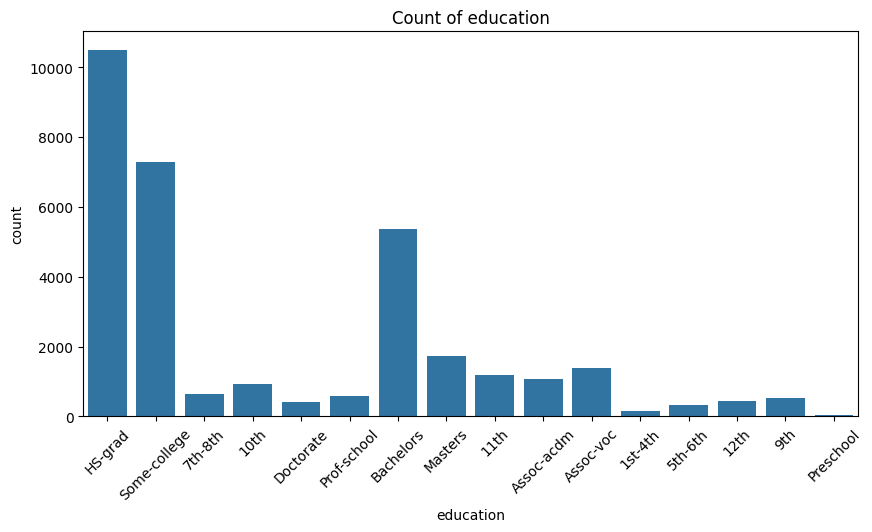

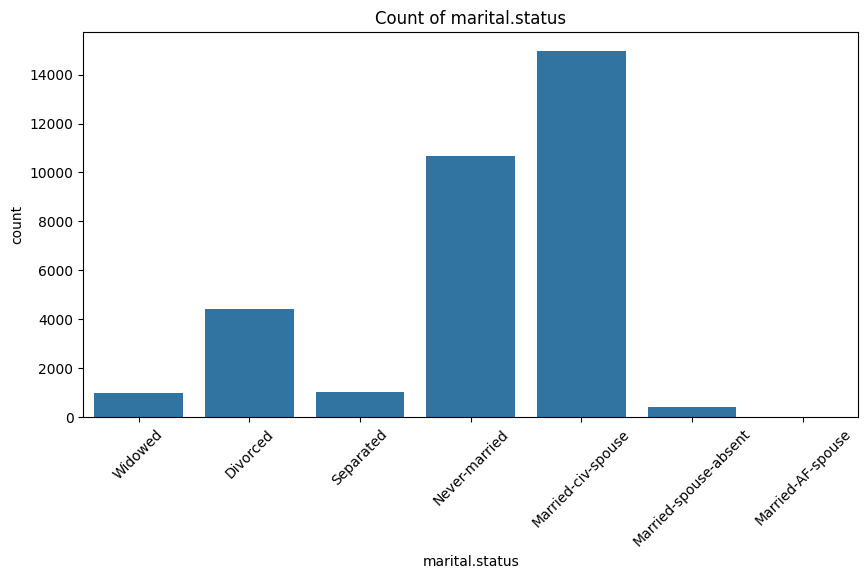

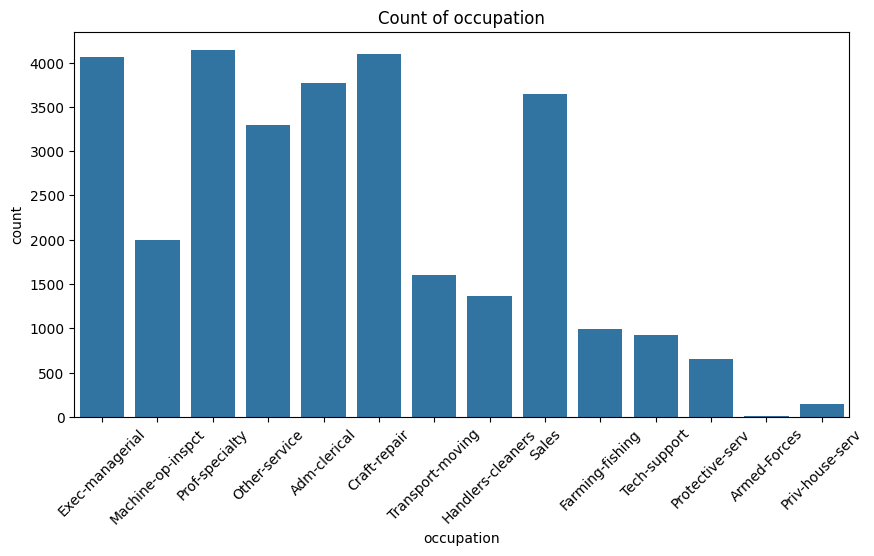

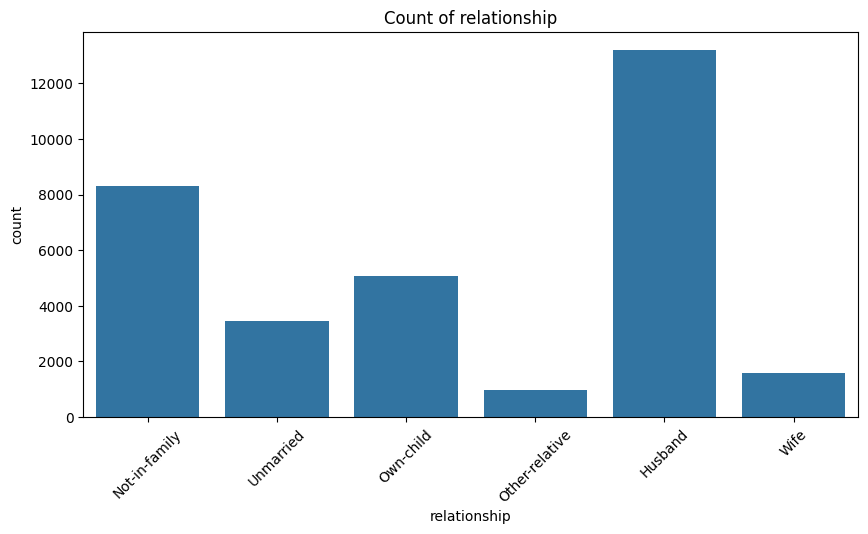

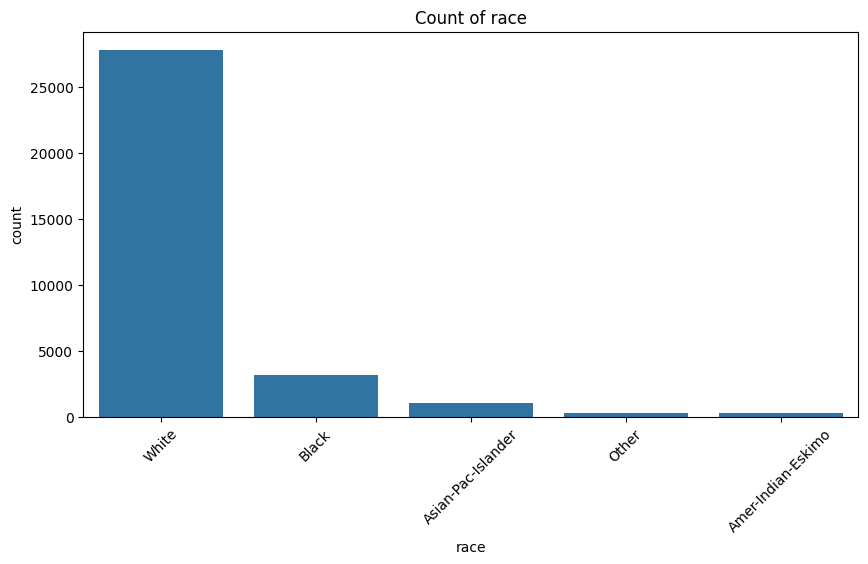

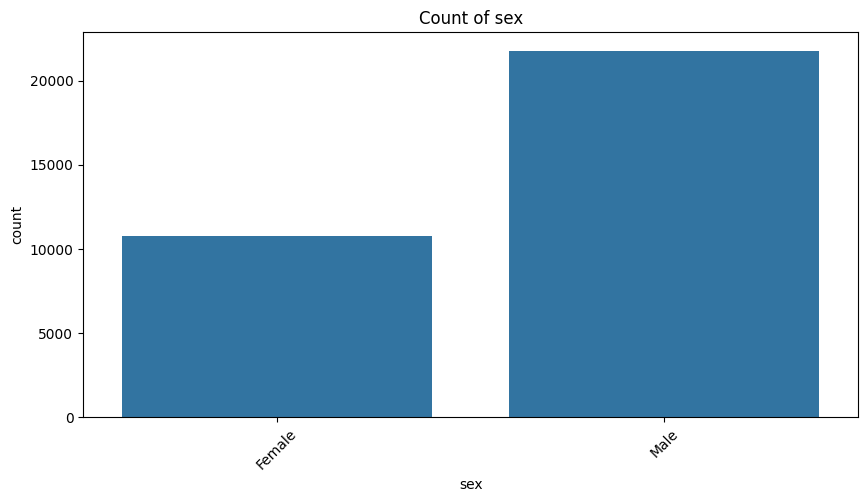

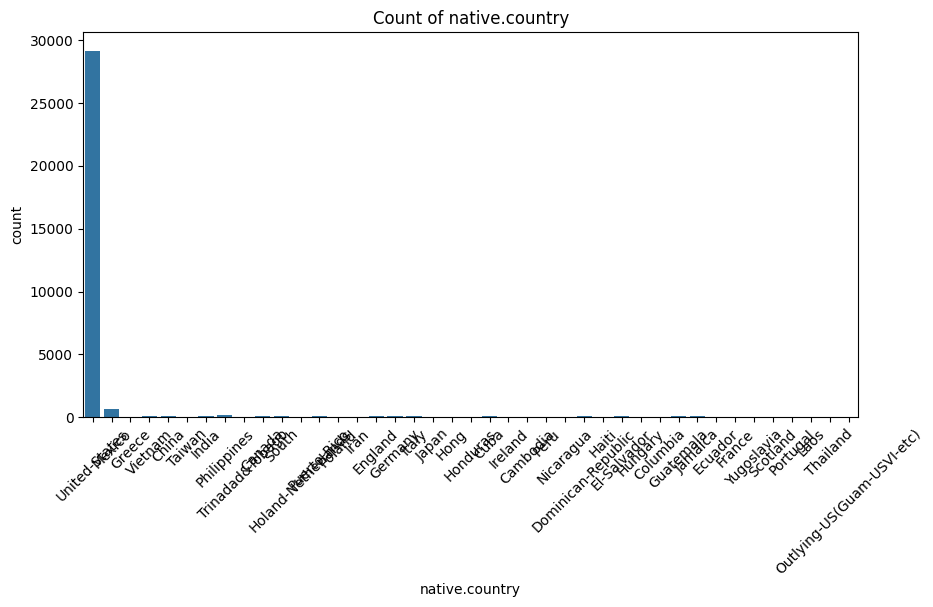

In [121]:
for i in cat_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=X[i])
    plt.title(f'Count of {i}')
    plt.xticks(rotation=45)
    plt.show()

### **Boxplot for Checking Outliers**

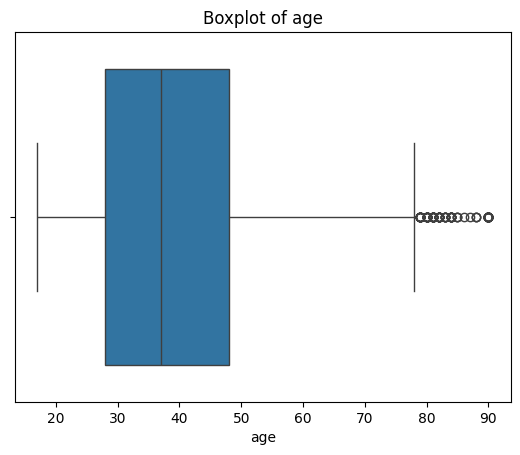

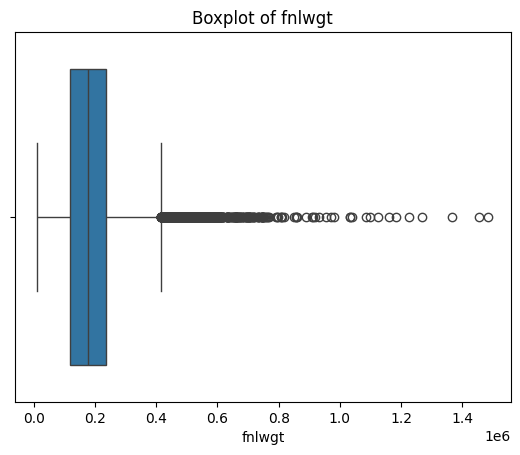

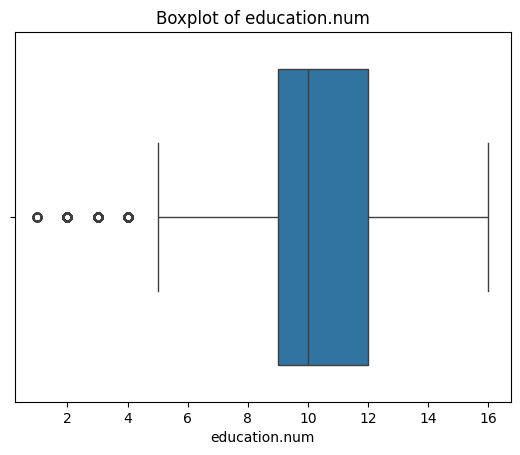

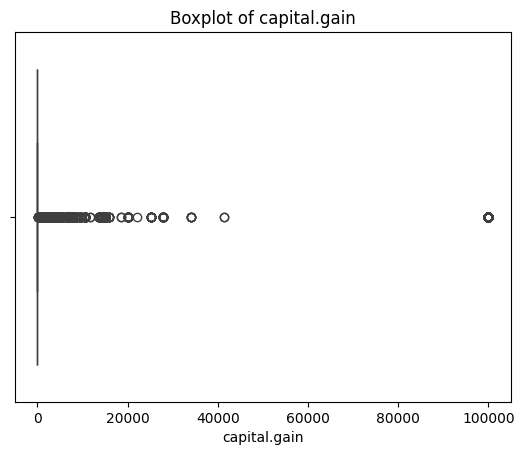

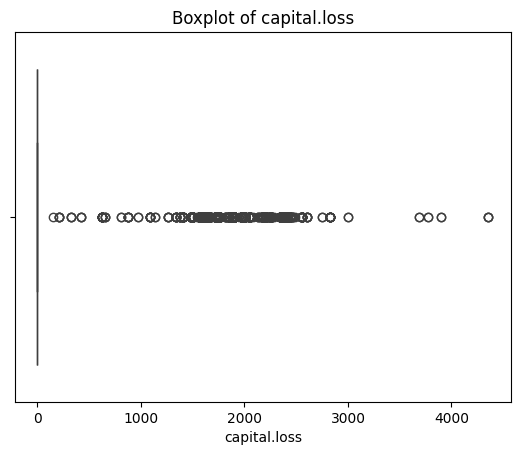

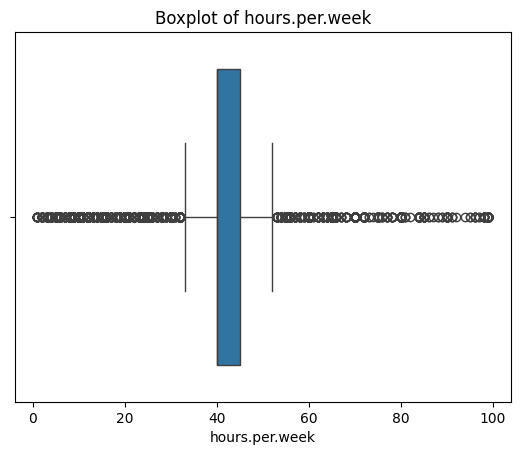

In [122]:
for i in num_features:
    sns.boxplot(x=data[i])
    plt.title(f'Boxplot of {i}')
    plt.show()

### **Correlation**

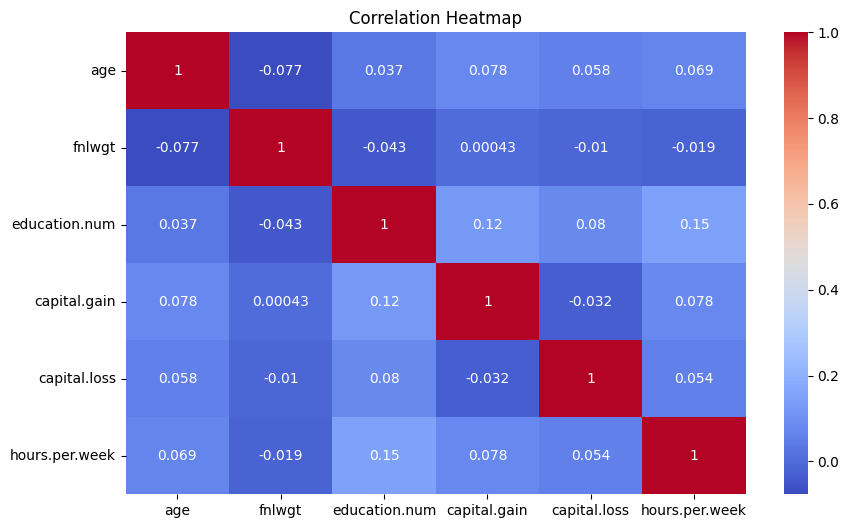

In [123]:
plt.figure(figsize=(10, 6))
sns.heatmap(data[num_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### **Target Variable**

In [124]:
data[['income']].value_counts(normalize=True).round(decimals=3)*100

income
<=50K     75.9
>50K      24.1
Name: proportion, dtype: float64

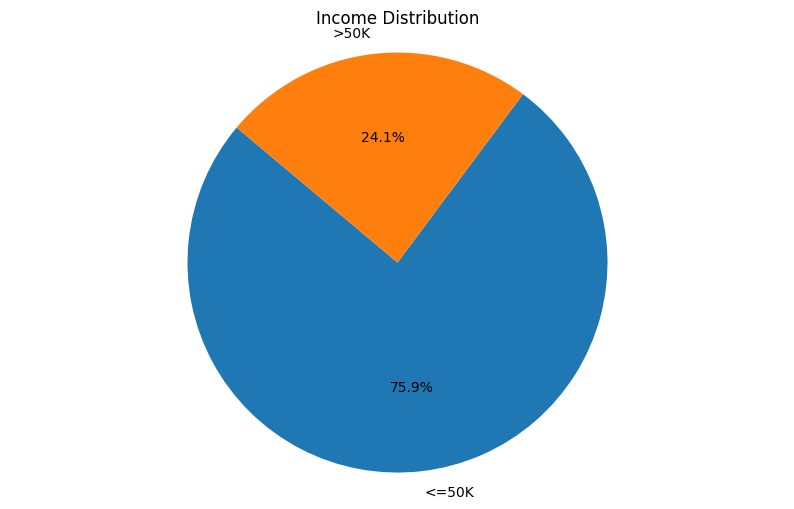

In [125]:
plt.figure(figsize=(10, 6))
plt.pie(data['income'].value_counts(), labels=data['income'].unique(), autopct='%1.1f%%', startangle=140)
plt.title('Income Distribution')
plt.axis('equal')
plt.show()

## **Preprocessing**

In [128]:
# Preprocessing (jika diperlukan)
def preprocess_data(X, y):
    """
    Preprocessing data adult census
    """

    
    return X_processed, y_processed, le_dict, le_y


# Uncomment jika perlu preprocessing
X_processed, y_processed, le_dict, le_y = preprocess_data(X, y)

# Split data (pakai hasil preprocessing!)
X_train, X_temp, y_train, y_temp = train_test_split(X_processed, y_processed, test_size=0.4, random_state=42, stratify=y_processed)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Data shape:")
print(f"X_train: {X_train_scaled.shape}")
print(f"X_val: {X_val_scaled.shape}")
print(f"X_test: {X_test_scaled.shape}")

Data shape:
X_train: (19536, 14)
X_val: (6512, 14)
X_test: (6513, 14)


### **Handling Missing Values**

In [129]:
data.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [130]:
data["workclass"].replace(np.nan, "Private", inplace=True)
data["occupation"].replace(np.nan, "Sales", inplace=True)
data["native.country"].replace(np.nan, "United-States", inplace=True)

In [131]:
data.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

### **Handling Outliers**

In [132]:
num_features = data.select_dtypes(include=['int64', 'float64'])
for col in num_features:
    data[col] = winsorize(data[col], limits=[0.01, 0.01])

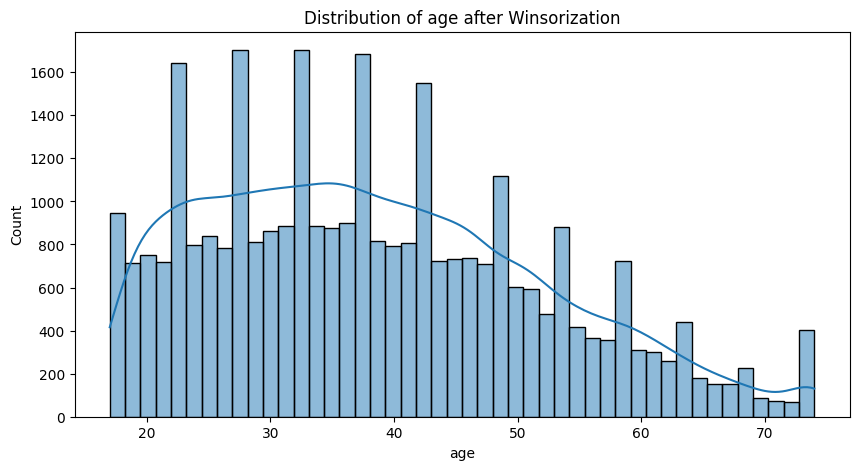

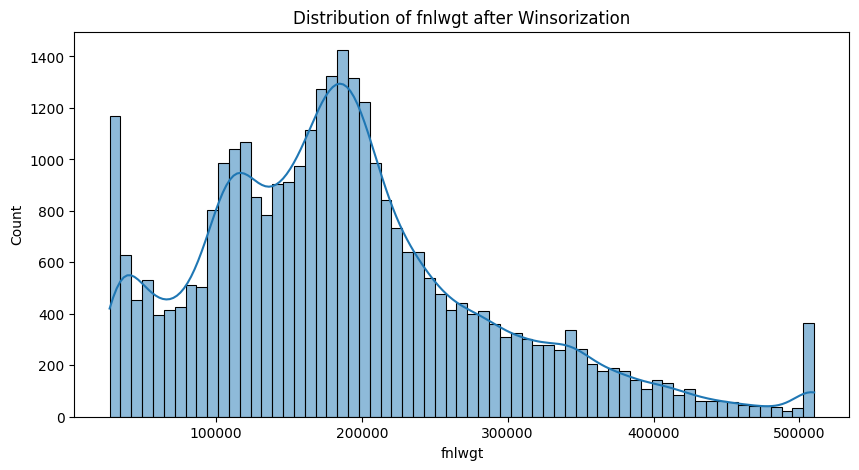

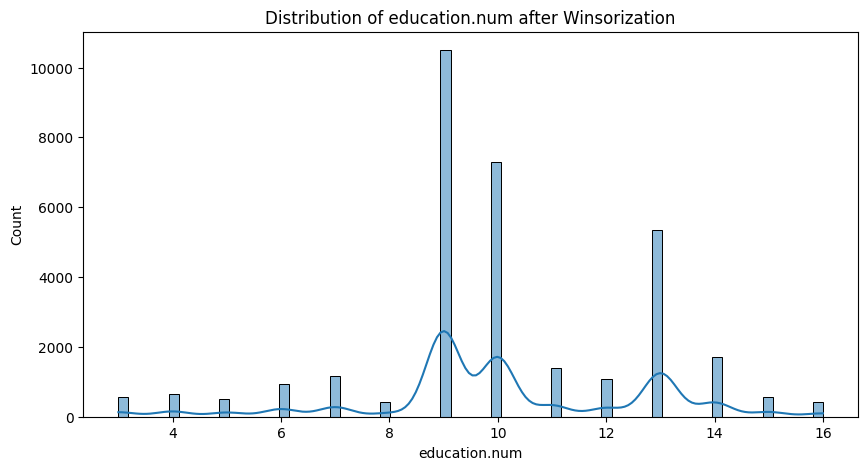

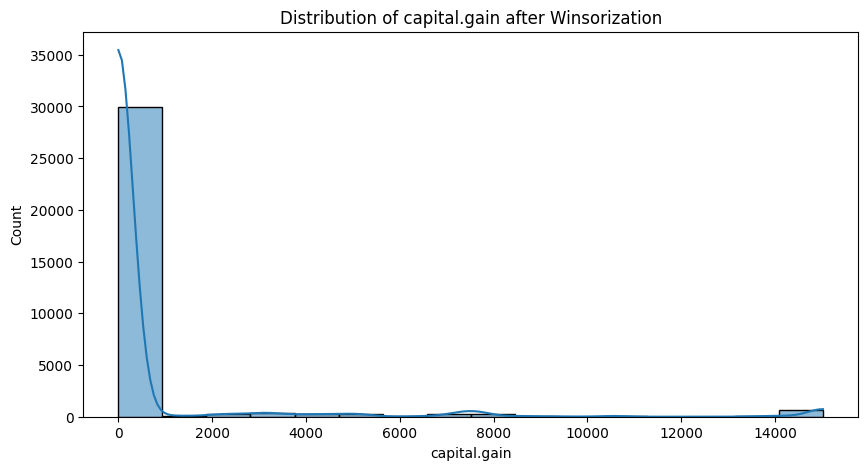

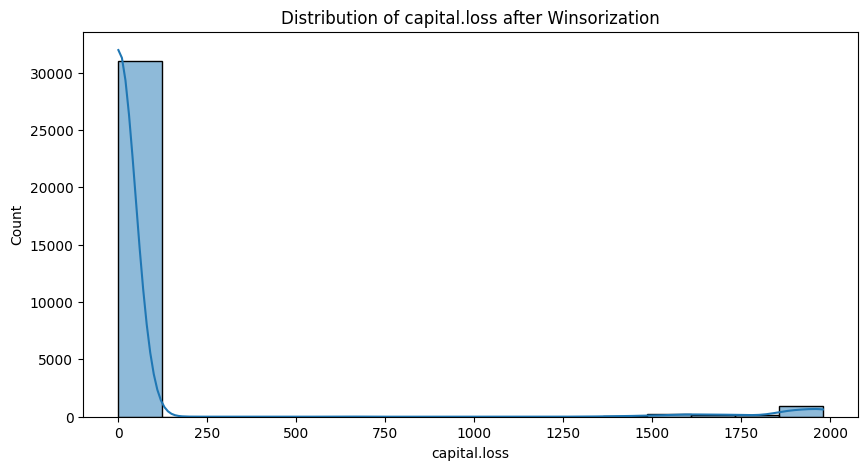

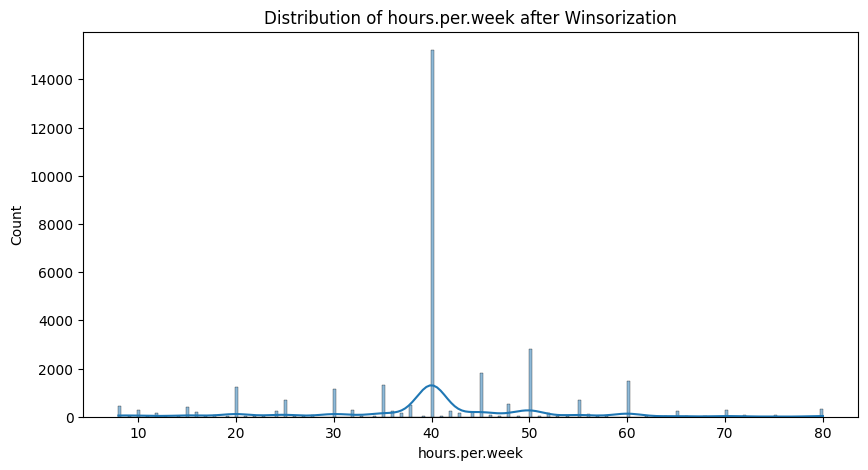

In [133]:
for i in num_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(data[i], kde=True)
    plt.title(f'Distribution of {i} after Winsorization')
    plt.show()

### **Encoding**

In [134]:
# Label encoding untuk categorical variables
le_dict = {}
X_processed = X.copy()

for col in cat_features:
    le = LabelEncoder()
    X_processed[col] = le.fit_transform(X_processed[col].astype(str))
    le_dict[col] = le

# Label encoding untuk target variable
le_y = LabelEncoder()
y_processed = le_y.fit_transform(y)

### **Train Test Split**

we split the data into 2, 80% of the data for training data and 20% of the data for validation

In [135]:
X_train, X_val, y_train, y_val = train_test_split(X_processed, y_processed, test_size=0.2, random_state=42)

### **Handling Imbalanced Data**

In [148]:
Counter(y_train)

Counter({0: 19744, 1: 6304})

In [136]:
print("=" * 80)
print("METODE IMBALANCE HANDLING - ADASYN")
print("=" * 80)

# Inisialisasi RandomOverSampler
ada = ADASYN(random_state=42)

# Lakukan oversampling pada data training
X_train_balanced, y_train_balanced = ada.fit_resample(X_train, y_train)

print("After RandomOverSampler:")
print(f"X_train shape: {X_train_balanced.shape}")
print(f"Class distribution: {Counter(y_train_balanced)}")

METODE IMBALANCE HANDLING - ADASYN
After RandomOverSampler:
X_train shape: (39904, 14)
Class distribution: Counter({1: 20160, 0: 19744})


### **Scaling**

In [139]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_val_scaled = scaler.transform(X_val)

## **Modelling**

### Raw Decision Tree

In [140]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_scaled, y_train_balanced)
y_pred_dt = model_dt.predict(X_val_scaled)

print("Decision Tree Accuracy:", accuracy_score(y_val, y_pred_dt))
print("Decision Tree Precision:", precision_score(y_val, y_pred_dt))
print("Decision Tree Recall:", recall_score(y_val, y_pred_dt))
print("Decision Tree f1-score:", f1_score(y_val, y_pred_dt))
print("Classification Report:")
print(classification_report(y_val, y_pred_dt, target_names=le_y.classes_))


Decision Tree Accuracy: 0.7979425763856901
Decision Tree Precision: 0.5631789594053745
Decision Tree Recall: 0.6408588158750813
Decision Tree f1-score: 0.5995130858186245
Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.85      0.86      4976
        >50K       0.56      0.64      0.60      1537

    accuracy                           0.80      6513
   macro avg       0.72      0.74      0.73      6513
weighted avg       0.81      0.80      0.80      6513



### Raw KNN

In [141]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_scaled, y_train_balanced)
y_pred_knn = model_knn.predict(X_val_scaled)

print("KNN Accuracy:", accuracy_score(y_val, y_pred_knn))
print("KNN Precision:", precision_score(y_val, y_pred_knn))
print("KNN Recall:", recall_score(y_val, y_pred_knn))
print("KNN f1-score:", f1_score(y_val, y_pred_knn))
print("Classification Report:")
print(classification_report(y_val, y_pred_knn, target_names=le_y.classes_))

KNN Accuracy: 0.801320436050975
KNN Precision: 0.5622119815668203
KNN Recall: 0.7143786597267404
KNN f1-score: 0.6292263610315186
Classification Report:
              precision    recall  f1-score   support

       <=50K       0.90      0.83      0.86      4976
        >50K       0.56      0.71      0.63      1537

    accuracy                           0.80      6513
   macro avg       0.73      0.77      0.75      6513
weighted avg       0.82      0.80      0.81      6513



## **Optimization**

### **Genetic Algorithm**

In [142]:
class GeneticAlgorithm:
    """
    Genetic Algorithm untuk hyperparameter tuning
    """
    def __init__(self, param_bounds: Dict, population_size: int = 50, 
                 mutation_rate: float = 0.1, crossover_rate: float = 0.8,
                 max_generations: int = 100, convergence_threshold: float = 1e-6,
                 convergence_generations: int = 10):
        self.param_bounds = param_bounds
        self.population_size = population_size
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.max_generations = max_generations
        self.convergence_threshold = convergence_threshold
        self.convergence_generations = convergence_generations
        self.fitness_history = []
        self.best_fitness_history = []
        
    def create_individual(self) -> List:
        """Membuat individu random"""
        individual = []
        for param, (min_val, max_val, param_type) in self.param_bounds.items():
            if param_type == 'int':
                individual.append(random.randint(min_val, max_val))
            elif param_type == 'float':
                individual.append(random.uniform(min_val, max_val))
            elif param_type == 'choice':
                individual.append(random.choice(min_val))  # min_val berisi list pilihan
        return individual
    
    def create_population(self) -> List[List]:
        """Membuat populasi awal"""
        return [self.create_individual() for _ in range(self.population_size)]
    
    def evaluate_fitness(self, individual: List, model_class, X_train_scaled, y_train_balanced, X_val_scaled, y_val) -> float:
        """Evaluasi fitness individu"""
        try:
            params = self.decode_individual(individual)
            model = model_class(**params)
            model.fit(X_train_scaled, y_train_balanced)
            y_pred = model.predict(X_val_scaled)
            return accuracy_score(y_val, y_pred)
        except:
            return 0.0
    
    def decode_individual(self, individual: List) -> Dict:
        """Decode individu menjadi parameter"""
        params = {}
        for i, (param, (min_val, max_val, param_type)) in enumerate(self.param_bounds.items()):
            if param_type == 'int':
                params[param] = int(individual[i])
            elif param_type == 'float':
                params[param] = individual[i]
            elif param_type == 'choice':
                params[param] = individual[i]
        return params
    
    def selection(self, population: List[List], fitness_scores: List[float]) -> List[List]:
        """Tournament selection"""
        selected = []
        for _ in range(len(population)):
            # Tournament size = 3
            tournament_indices = random.sample(range(len(population)), 3)
            tournament_fitness = [fitness_scores[i] for i in tournament_indices]
            winner_idx = tournament_indices[tournament_fitness.index(max(tournament_fitness))]
            selected.append(population[winner_idx].copy())
        return selected
    
    def crossover(self, parent1: List, parent2: List) -> Tuple[List, List]:
        """Single point crossover"""
        if random.random() < self.crossover_rate:
            crossover_point = random.randint(1, len(parent1) - 1)
            child1 = parent1[:crossover_point] + parent2[crossover_point:]
            child2 = parent2[:crossover_point] + parent1[crossover_point:]
            return child1, child2
        return parent1.copy(), parent2.copy()
    
    def mutate(self, individual: List) -> List:
        """Mutasi individu"""
        mutated = individual.copy()
        for i, (param, (min_val, max_val, param_type)) in enumerate(self.param_bounds.items()):
            if random.random() < self.mutation_rate:
                if param_type == 'int':
                    mutated[i] = random.randint(min_val, max_val)
                elif param_type == 'float':
                    mutated[i] = random.uniform(min_val, max_val)
                elif param_type == 'choice':
                    mutated[i] = random.choice(min_val)
        return mutated
    
    def check_convergence(self) -> bool:
        """Cek konvergensi berdasarkan fitness history"""
        if len(self.best_fitness_history) < self.convergence_generations:
            return False
        
        recent_fitness = self.best_fitness_history[-self.convergence_generations:]
        fitness_std = np.std(recent_fitness)
        
        return fitness_std < self.convergence_threshold
    
    def optimize(self, model_class, X_train_scaled, y_train_balanced, X_val_scaled, y_val) -> Tuple[Dict, float, List]:
        """Proses optimasi GA"""
        print(f"Starting GA optimization for {model_class.__name__}...")
        
        # Inisialisasi populasi
        population = self.create_population()
        
        for generation in range(self.max_generations):
            # Evaluasi fitness
            fitness_scores = [
                self.evaluate_fitness(ind, model_class, X_train_scaled, y_train_balanced, X_val_scaled, y_val)
                for ind in population
            ]
            
            # Simpan statistik
            avg_fitness = np.mean(fitness_scores)
            best_fitness = max(fitness_scores)
            self.fitness_history.append(avg_fitness)
            self.best_fitness_history.append(best_fitness)
            
            print(f"Generation {generation + 1}: Best Fitness = {best_fitness:.4f}, Avg Fitness = {avg_fitness:.4f}")
            
            # Cek konvergensi
            if self.check_convergence():
                print(f"Converged at generation {generation + 1}")
                break
            
            # Seleksi
            selected_population = self.selection(population, fitness_scores)
            
            # Crossover dan Mutasi
            new_population = []
            for i in range(0, len(selected_population), 2):
                parent1 = selected_population[i]
                parent2 = selected_population[i + 1 if i + 1 < len(selected_population) else 0]
                
                child1, child2 = self.crossover(parent1, parent2)
                child1 = self.mutate(child1)
                child2 = self.mutate(child2)
                
                new_population.extend([child1, child2])
            
            population = new_population[:self.population_size]
        
        # Return best solution
        final_fitness = [
            self.evaluate_fitness(ind, model_class, X_train_scaled, y_train_balanced, X_val_scaled, y_val)
            for ind in population
        ]
        best_idx = final_fitness.index(max(final_fitness))
        best_params = self.decode_individual(population[best_idx])
        
        return best_params, max(final_fitness), self.best_fitness_history



### **Particle Swarm Optimization**

In [ ]:
class ParticleSwarmOptimization:
    """
    Particle Swarm Optimization untuk hyperparameter tuning
    """
    def __init__(self, param_bounds: Dict, n_particles: int = 30, max_iterations: int = 100,
                 w: float = 0.729, c1: float = 1.494, c2: float = 1.494,
                 convergence_threshold: float = 1e-6, convergence_iterations: int = 10):
        self.param_bounds = param_bounds
        self.n_particles = n_particles
        self.max_iterations = max_iterations
        self.w = w  # inertia weight
        self.c1 = c1  # cognitive parameter
        self.c2 = c2  # social parameter
        self.convergence_threshold = convergence_threshold
        self.convergence_iterations = convergence_iterations
        self.fitness_history = []
        self.best_fitness_history = []
        
        # Initialize particles
        self.particles = []
        self.velocities = []
        self.personal_best = []
        self.personal_best_fitness = []
        self.global_best = None
        self.global_best_fitness = -np.inf
        
    def initialize_particles(self):
        """Inisialisasi partikel"""
        self.particles = []
        self.velocities = []
        self.personal_best = []
        self.personal_best_fitness = []
        
        for _ in range(self.n_particles):
            particle = []
            velocity = []
            
            for param, (min_val, max_val, param_type) in self.param_bounds.items():
                if param_type == 'int':
                    particle.append(random.randint(min_val, max_val))
                    velocity.append(random.uniform(-1, 1))
                elif param_type == 'float':
                    particle.append(random.uniform(min_val, max_val))
                    velocity.append(random.uniform(-0.1, 0.1))
                elif param_type == 'choice':
                    particle.append(random.choice(min_val))
                    velocity.append(0)  # No velocity for categorical
            
            self.particles.append(particle)
            self.velocities.append(velocity)
            self.personal_best.append(particle.copy())
            self.personal_best_fitness.append(-np.inf)
    
    def evaluate_fitness(self, particle: List, model_class, X_train_scaled, y_train_balanced, X_val_scaled, y_val) -> float:
        """Evaluasi fitness partikel"""
        try:
            params = self.decode_particle(particle)
            model = model_class(**params)
            model.fit(X_train_scaled, y_train_balanced)
            y_pred = model.predict(X_val_scaled)
            return accuracy_score(y_val, y_pred)
        except:
            return 0.0
    
    def decode_particle(self, particle: List) -> Dict:
        """Decode partikel menjadi parameter"""
        params = {}
        for i, (param, (min_val, max_val, param_type)) in enumerate(self.param_bounds.items()):
            if param_type == 'int':
                params[param] = int(max(min_val, min(max_val, particle[i])))
            elif param_type == 'float':
                params[param] = max(min_val, min(max_val, particle[i]))
            elif param_type == 'choice':
                params[param] = particle[i]
        return params
    
    def update_velocity_and_position(self, particle_idx: int):
        """Update velocity dan posisi partikel"""
        for i, (param, (min_val, max_val, param_type)) in enumerate(self.param_bounds.items()):
            if param_type != 'choice':  # Skip categorical parameters
                r1, r2 = random.random(), random.random()
                
                cognitive = self.c1 * r1 * (self.personal_best[particle_idx][i] - self.particles[particle_idx][i])
                social = self.c2 * r2 * (self.global_best[i] - self.particles[particle_idx][i])
                
                # Update velocity
                self.velocities[particle_idx][i] = (
                    self.w * self.velocities[particle_idx][i] + cognitive + social
                )
                
                # Update position
                self.particles[particle_idx][i] += self.velocities[particle_idx][i]
                
                # Bound checking
                if param_type == 'int':
                    self.particles[particle_idx][i] = max(min_val, min(max_val, 
                                                        round(self.particles[particle_idx][i])))
                elif param_type == 'float':
                    self.particles[particle_idx][i] = max(min_val, min(max_val, 
                                                        self.particles[particle_idx][i]))
    
    def check_convergence(self) -> bool:
        """Cek konvergensi berdasarkan fitness history"""
        if len(self.best_fitness_history) < self.convergence_iterations:
            return False
        
        recent_fitness = self.best_fitness_history[-self.convergence_iterations:]
        fitness_std = np.std(recent_fitness)
        
        return fitness_std < self.convergence_threshold
    
    def optimize(self, model_class, X_train_scaled, y_train_balanced, X_val_scaled, y_val) -> Tuple[Dict, float, List]:
        """Proses optimasi PSO"""
        print(f"Starting PSO optimization for {model_class.__name__}...")
        
        # Initialize particles
        self.initialize_particles()
        
        for iteration in range(self.max_iterations):
            fitness_scores = []
            
            # Evaluate all particles
            for i, particle in enumerate(self.particles):
                fitness = self.evaluate_fitness(particle, model_class, X_train_scaled, y_train_balanced, X_val_scaled, y_val)
                fitness_scores.append(fitness)
                
                # Update personal best
                if fitness > self.personal_best_fitness[i]:
                    self.personal_best_fitness[i] = fitness
                    self.personal_best[i] = particle.copy()
                
                # Update global best
                if fitness > self.global_best_fitness:
                    self.global_best_fitness = fitness
                    self.global_best = particle.copy()
            
            # Save statistics
            avg_fitness = np.mean(fitness_scores)
            best_fitness = max(fitness_scores)
            self.fitness_history.append(avg_fitness)
            self.best_fitness_history.append(best_fitness)
            
            print(f"Iteration {iteration + 1}: Best Fitness = {best_fitness:.4f}, Avg Fitness = {avg_fitness:.4f}")
            
            # Check convergence
            if self.check_convergence():
                print(f"Converged at iteration {iteration + 1}")
                break
            
            # Update particles
            for i in range(self.n_particles):
                self.update_velocity_and_position(i)
        
        return self.decode_particle(self.global_best), self.global_best_fitness, self.best_fitness_history

### **Tuning**

In [144]:
def plot_convergence(ga_history: List, pso_history: List, model_name: str):
    """Plot konvergensi GA dan PSO"""
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(ga_history, 'b-', label='GA', linewidth=2)
    plt.title(f'GA Convergence - {model_name}')
    plt.xlabel('Generation')
    plt.ylabel('Best Fitness')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(pso_history, 'r-', label='PSO', linewidth=2)
    plt.title(f'PSO Convergence - {model_name}')
    plt.xlabel('Iteration')
    plt.ylabel('Best Fitness')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()


def compare_algorithms(ga_results: Dict, pso_results: Dict, model_name: str):
    """Bandingkan hasil GA dan PSO"""
    print(f"\n{'='*50}")
    print(f"COMPARISON RESULTS - {model_name}")
    print(f"{'='*50}")
    
    print(f"\nGA Results:")
    print(f"Best Parameters: {ga_results['params']}")
    print(f"Best Fitness: {ga_results['fitness']:.4f}")
    print(f"Generations: {len(ga_results['history'])}")
    
    print(f"\nPSO Results:")
    print(f"Best Parameters: {pso_results['params']}")
    print(f"Best Fitness: {pso_results['fitness']:.4f}")
    print(f"Iterations: {len(pso_results['history'])}")
    
    print(f"\nWinner: {'GA' if ga_results['fitness'] > pso_results['fitness'] else 'PSO'}")
    print(f"Performance Difference: {abs(ga_results['fitness'] - pso_results['fitness']):.4f}")


# Parameter bounds untuk setiap model
DT_PARAM_BOUNDS = {
    'max_depth': (3, 20, 'int'),
    'min_samples_split': (2, 20, 'int'),
    'min_samples_leaf': (1, 10, 'int'),
    'criterion': (['gini', 'entropy'], None, 'choice')
}

KNN_PARAM_BOUNDS = {
    'n_neighbors': (3, 50, 'int'),
    'weights': (['uniform', 'distance'], None, 'choice'),
    'p': (1, 2, 'int'),  # 1 for manhattan, 2 for euclidean
    'algorithm': (['auto', 'ball_tree', 'kd_tree', 'brute'], None, 'choice')
}

Starting Hyperparameter Tuning Analysis...
Models: Decision Tree, KNN
Optimization Algorithms: GA, PSO
Dataset: Adult Income Census

OPTIMIZING DECISION TREE

----------------------------------------
GENETIC ALGORITHM
----------------------------------------
Starting GA optimization for DecisionTreeClassifier...
Generation 1: Best Fitness = 0.8354, Avg Fitness = 0.7912
Generation 2: Best Fitness = 0.8354, Avg Fitness = 0.8281
Generation 3: Best Fitness = 0.8354, Avg Fitness = 0.8315
Generation 4: Best Fitness = 0.8363, Avg Fitness = 0.8300
Generation 5: Best Fitness = 0.8363, Avg Fitness = 0.8330
Generation 6: Best Fitness = 0.8363, Avg Fitness = 0.8339
Generation 7: Best Fitness = 0.8363, Avg Fitness = 0.8357
Generation 8: Best Fitness = 0.8363, Avg Fitness = 0.8346
Converged at generation 8
GA completed in 72.29 seconds
Best GA parameters: {'max_depth': 10, 'min_samples_split': 12, 'min_samples_leaf': 10, 'criterion': 'gini'}
Best GA fitness: 0.8363

---------------------------------

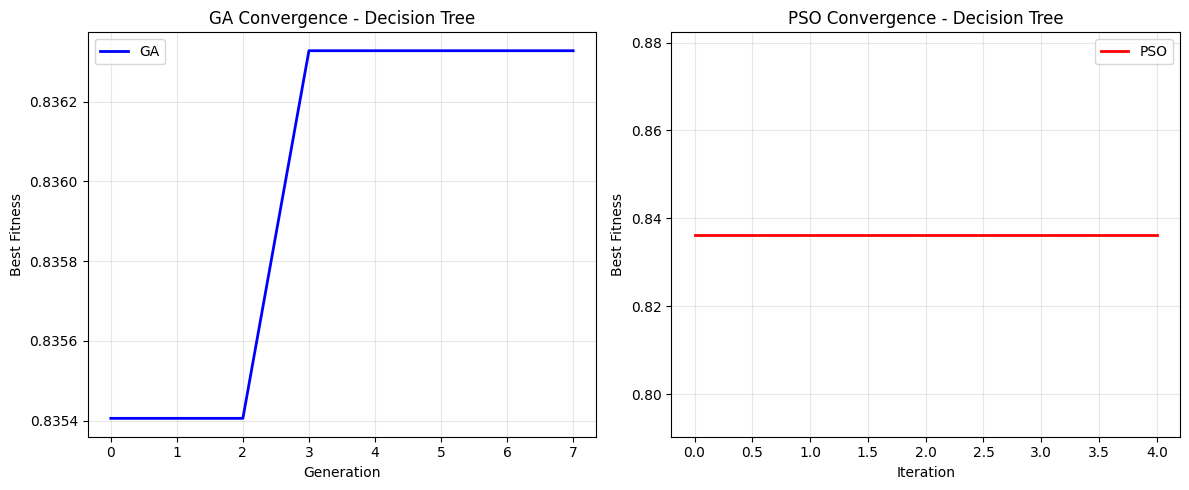


OPTIMIZING KNN

----------------------------------------
GENETIC ALGORITHM
----------------------------------------
Starting GA optimization for KNeighborsClassifier...
Generation 1: Best Fitness = 0.8244, Avg Fitness = 0.8056
Generation 2: Best Fitness = 0.8244, Avg Fitness = 0.8130
Generation 3: Best Fitness = 0.8273, Avg Fitness = 0.8223
Generation 4: Best Fitness = 0.8273, Avg Fitness = 0.8233
Generation 5: Best Fitness = 0.8280, Avg Fitness = 0.8227
Generation 6: Best Fitness = 0.8280, Avg Fitness = 0.8252
Generation 7: Best Fitness = 0.8280, Avg Fitness = 0.8237
Generation 8: Best Fitness = 0.8280, Avg Fitness = 0.8249
Generation 9: Best Fitness = 0.8280, Avg Fitness = 0.8275
Converged at generation 9
GA completed in 4817.17 seconds
Best GA parameters: {'n_neighbors': 22, 'weights': 'uniform', 'p': 1, 'algorithm': 'auto'}
Best GA fitness: 0.8280

----------------------------------------
PARTICLE SWARM OPTIMIZATION
----------------------------------------
Starting PSO optimizatio

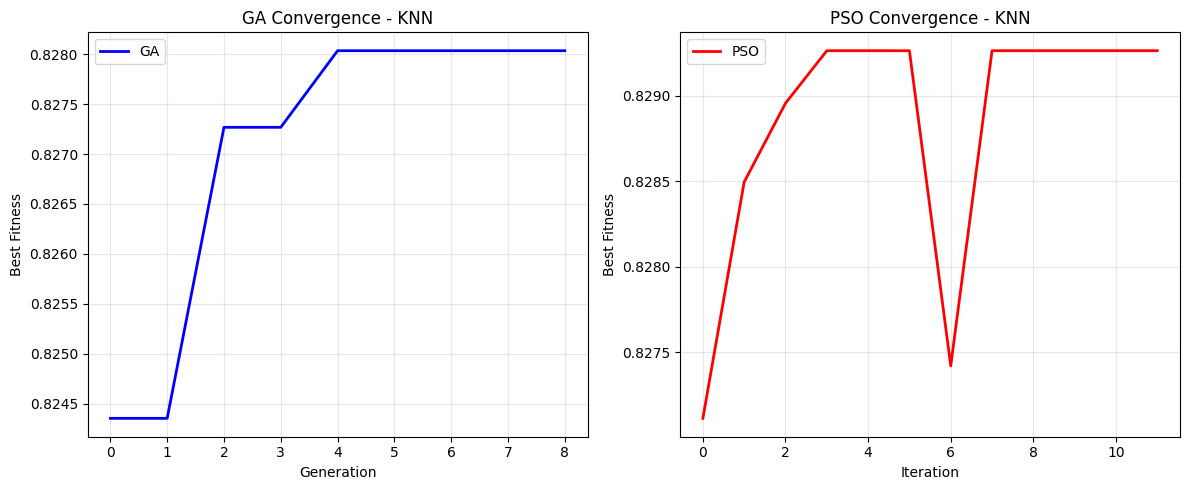


FINAL EVALUATION ON TEST SET

----------------------------------------
DECISION TREE EVALUATION
----------------------------------------
Best algorithm: PSO
Best parameters: {'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 10, 'criterion': 'gini'}
Test Accuracy: 0.8363

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4976
           1       0.64      0.69      0.66      1537

    accuracy                           0.84      6513
   macro avg       0.77      0.78      0.78      6513
weighted avg       0.84      0.84      0.84      6513


----------------------------------------
KNN EVALUATION
----------------------------------------
Best algorithm: PSO
Best parameters: {'n_neighbors': 20, 'weights': 'uniform', 'p': 1, 'algorithm': 'brute'}
Test Accuracy: 0.8293

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4976
   

In [145]:
# ============================================================================
# HYPERPARAMETER TUNING DENGAN GA DAN PSO
# ============================================================================

def run_hyperparameter_tuning():
    """
    Menjalankan hyperparameter tuning untuk DT dan KNN menggunakan GA dan PSO
    """
    results = {}
    
    # Models to optimize
    models = {
        'Decision Tree': (DecisionTreeClassifier, DT_PARAM_BOUNDS),
        'KNN': (KNeighborsClassifier, KNN_PARAM_BOUNDS)
    }
    
    for model_name, (model_class, param_bounds) in models.items():
        print(f"\n{'='*60}")
        print(f"OPTIMIZING {model_name.upper()}")
        print(f"{'='*60}")
        
        results[model_name] = {}
        
        # =============================================
        # GENETIC ALGORITHM
        # =============================================
        print(f"\n{'-'*40}")
        print("GENETIC ALGORITHM")
        print(f"{'-'*40}")
        
        ga = GeneticAlgorithm(
            param_bounds=param_bounds,
            population_size=30,
            mutation_rate=0.1,
            crossover_rate=0.8,
            max_generations=50,
            convergence_threshold=1e-4,
            convergence_generations=5
        )
        
        start_time = time.time()
        ga_params, ga_fitness, ga_history = ga.optimize(
            model_class, X_train_scaled, y_train_balanced, X_val_scaled, y_val
        )
        ga_time = time.time() - start_time
        
        results[model_name]['GA'] = {
            'params': ga_params,
            'fitness': ga_fitness,
            'history': ga_history,
            'time': ga_time
        }
        
        print(f"GA completed in {ga_time:.2f} seconds")
        print(f"Best GA parameters: {ga_params}")
        print(f"Best GA fitness: {ga_fitness:.4f}")
        
        # =============================================
        # PARTICLE SWARM OPTIMIZATION
        # =============================================
        print(f"\n{'-'*40}")
        print("PARTICLE SWARM OPTIMIZATION")
        print(f"{'-'*40}")
        
        pso = ParticleSwarmOptimization(
            param_bounds=param_bounds,
            n_particles=30,
            max_iterations=50,
            w=0.729,
            c1=1.494,
            c2=1.494,
            convergence_threshold=1e-4,
            convergence_iterations=5
        )
        
        start_time = time.time()
        pso_params, pso_fitness, pso_history = pso.optimize(
            model_class, X_train_scaled, y_train_balanced, X_val_scaled, y_val
        )
        pso_time = time.time() - start_time
        
        results[model_name]['PSO'] = {
            'params': pso_params,
            'fitness': pso_fitness,
            'history': pso_history,
            'time': pso_time
        }
        
        print(f"PSO completed in {pso_time:.2f} seconds")
        print(f"Best PSO parameters: {pso_params}")
        print(f"Best PSO fitness: {pso_fitness:.4f}")
        
        # =============================================
        # COMPARISON DAN VISUALIZATION
        # =============================================
        compare_algorithms(
            results[model_name]['GA'], 
            results[model_name]['PSO'], 
            model_name
        )
        
        plot_convergence(ga_history, pso_history, model_name)
    
    return results

def evaluate_best_models(results):
    """
    Evaluasi model terbaik pada test set
    """
    print(f"\n{'='*60}")
    print("FINAL EVALUATION ON TEST SET")
    print(f"{'='*60}")
    
    models = {
        'Decision Tree': DecisionTreeClassifier,
        'KNN': KNeighborsClassifier
    }
    
    for model_name, model_class in models.items():
        print(f"\n{'-'*40}")
        print(f"{model_name.upper()} EVALUATION")
        print(f"{'-'*40}")
        
        # Get best parameters from GA and PSO
        ga_params = results[model_name]['GA']['params']
        pso_params = results[model_name]['PSO']['params']
        
        # Determine which algorithm performed better
        if results[model_name]['GA']['fitness'] > results[model_name]['PSO']['fitness']:
            best_params = ga_params
            best_algorithm = 'GA'
        else:
            best_params = pso_params
            best_algorithm = 'PSO'
        
        print(f"Best algorithm: {best_algorithm}")
        print(f"Best parameters: {best_params}")
        
        # Train final model
        final_model = model_class(**best_params)
        final_model.fit(X_train_scaled, y_train_balanced)
        
        # Predictions
        y_pred = final_model.predict(X_val_scaled)
        test_accuracy = accuracy_score(y_val, y_pred)
        
        print(f"Test Accuracy: {test_accuracy:.4f}")
        print(f"\nClassification Report:")
        print(classification_report(y_val, y_pred))

def create_summary_report(results):
    """
    Membuat laporan ringkasan hasil optimasi
    """
    print(f"\n{'='*60}")
    print("SUMMARY REPORT")
    print(f"{'='*60}")
    
    summary_data = []
    
    for model_name in results.keys():
        for algorithm in ['GA', 'PSO']:
            summary_data.append({
                'Model': model_name,
                'Algorithm': algorithm,
                'Best_Fitness': results[model_name][algorithm]['fitness'],
                'Convergence_Iterations': len(results[model_name][algorithm]['history']),
                'Time_Seconds': results[model_name][algorithm]['time'],
                'Parameters': str(results[model_name][algorithm]['params'])
            })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    # Find overall best performance
    best_idx = summary_df['Best_Fitness'].idxmax()
    best_result = summary_df.iloc[best_idx]
    
    print(f"\n{'='*40}")
    print("OVERALL BEST PERFORMANCE")
    print(f"{'='*40}")
    print(f"Model: {best_result['Model']}")
    print(f"Algorithm: {best_result['Algorithm']}")
    print(f"Fitness: {best_result['Best_Fitness']:.4f}")
    print(f"Convergence Time: {best_result['Time_Seconds']:.2f} seconds")
    print(f"Iterations: {best_result['Convergence_Iterations']}")
    
    return summary_df

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("Starting Hyperparameter Tuning Analysis...")
    print("Models: Decision Tree, KNN")
    print("Optimization Algorithms: GA, PSO")
    print("Dataset: Adult Income Census")
    
    # Run hyperparameter tuning
    results = run_hyperparameter_tuning()
    
    # Evaluate best models on test set
    evaluate_best_models(results)
    
    # Create summary report
    summary_df = create_summary_report(results)
    
    print("\nAnalysis completed!")
    
    # Optional: Save results
    # summary_df.to_csv('hyperparameter_tuning_results.csv', index=False)
    # print("Results saved to 'hyperparameter_tuning_results.csv'")

# ============================================================================
# ADDITIONAL ANALYSIS FUNCTIONS
# ============================================================================

def analyze_convergence_patterns(results):
    """
    Analisis pola konvergensi algoritma
    """
    print(f"\n{'='*60}")
    print("CONVERGENCE PATTERN ANALYSIS")
    print(f"{'='*60}")
    
    for model_name in results.keys():
        print(f"\n{model_name}:")
        
        ga_history = results[model_name]['GA']['history']
        pso_history = results[model_name]['PSO']['history']
        
        # Convergence speed analysis
        ga_convergence_speed = len(ga_history)
        pso_convergence_speed = len(pso_history)
        
        print(f"  GA convergence speed: {ga_convergence_speed} generations")
        print(f"  PSO convergence speed: {pso_convergence_speed} iterations")
        
        # Improvement rate analysis
        if len(ga_history) > 1:
            ga_improvement = ga_history[-1] - ga_history[0]
            print(f"  GA total improvement: {ga_improvement:.4f}")
        
        if len(pso_history) > 1:
            pso_improvement = pso_history[-1] - pso_history[0]
            print(f"  PSO total improvement: {pso_improvement:.4f}")

def parameter_sensitivity_analysis(model_class, param_bounds, X_train_scaled, y_train_balanced, X_val_scaled, y_val):
    """
    Analisis sensitivitas parameter
    """
    print(f"\n{'='*60}")
    print(f"PARAMETER SENSITIVITY ANALYSIS - {model_class.__name__}")
    print(f"{'='*60}")
    
    base_params = {}
    for param, (min_val, max_val, param_type) in param_bounds.items():
        if param_type == 'int':
            base_params[param] = (min_val + max_val) // 2
        elif param_type == 'float':
            base_params[param] = (min_val + max_val) / 2
        elif param_type == 'choice':
            base_params[param]

##  **Evaluation**

=== EVALUASI SEBELUM TUNING ===
Decision Tree (Original) - Accuracy : 0.7979
Decision Tree (Original) - Precision: 0.5632
Decision Tree (Original) - Recall   : 0.6409
Decision Tree (Original) - F1 Score : 0.5995
----------------------------------------
KNN (Original) - Accuracy : 0.8013
KNN (Original) - Precision: 0.5622
KNN (Original) - Recall   : 0.7144
KNN (Original) - F1 Score : 0.6292
----------------------------------------

=== EVALUASI SESUDAH TUNING ===
Decision Tree (GA) - Accuracy : 0.8363
Decision Tree (GA) - Precision: 0.6440
Decision Tree (GA) - Recall   : 0.6851
Decision Tree (GA) - F1 Score : 0.6639
----------------------------------------
Decision Tree (PSO) - Accuracy : 0.8363
Decision Tree (PSO) - Precision: 0.6440
Decision Tree (PSO) - Recall   : 0.6851
Decision Tree (PSO) - F1 Score : 0.6639
----------------------------------------
KNN (GA) - Accuracy : 0.8280
KNN (GA) - Precision: 0.6245
KNN (GA) - Recall   : 0.6805
KNN (GA) - F1 Score : 0.6513
-------------------

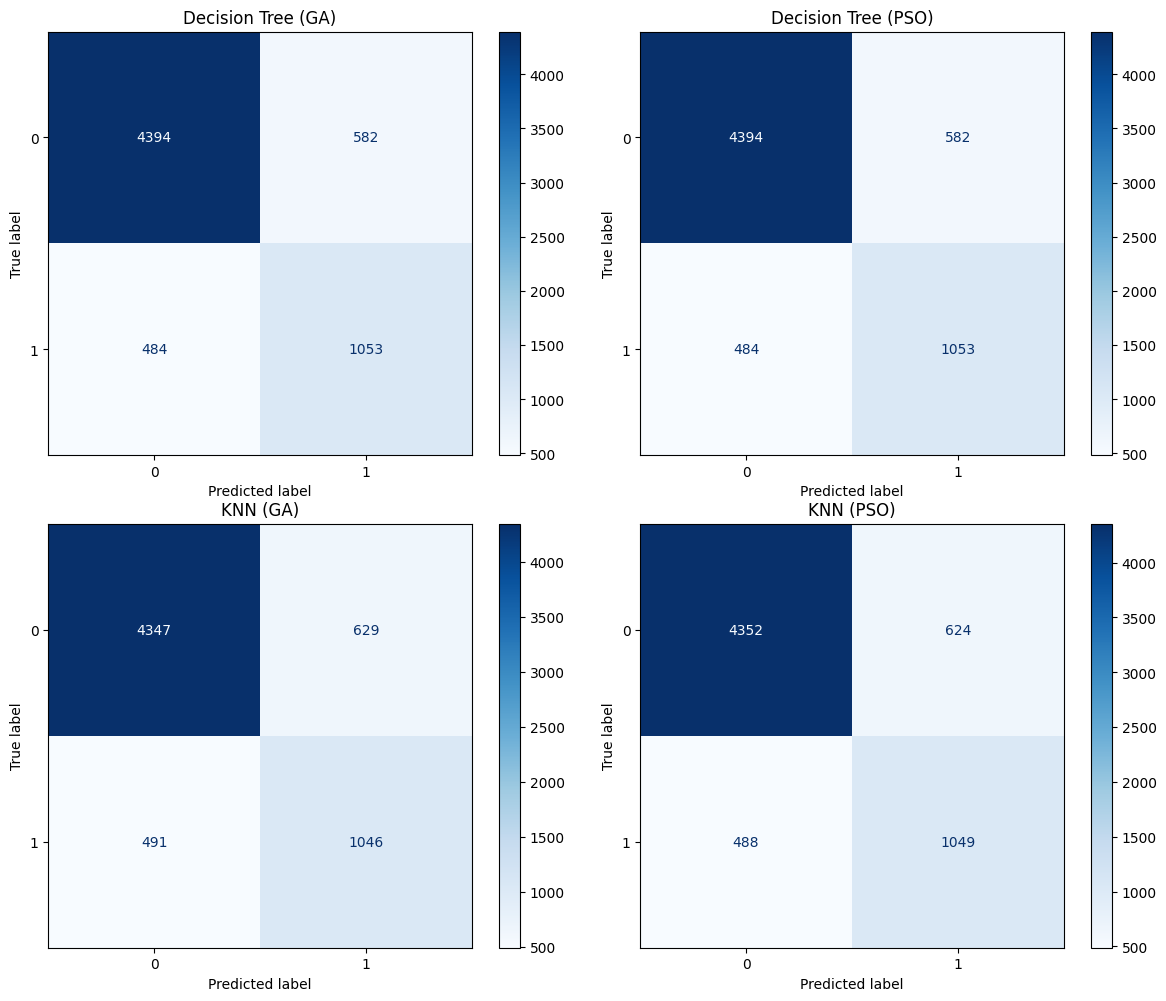

In [146]:
def print_scores(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{model_name} - Accuracy : {acc:.4f}")
    print(f"{model_name} - Precision: {prec:.4f}")
    print(f"{model_name} - Recall   : {rec:.4f}")
    print(f"{model_name} - F1 Score : {f1:.4f}")
    print("-" * 40)
    return acc, prec, rec, f1

# Evaluasi model sebelum tuning
print("=== EVALUASI SEBELUM TUNING ===")
print_scores(y_val, y_pred_dt, "Decision Tree (Original)")
print_scores(y_val, y_pred_knn, "KNN (Original)")

# Evaluasi model sesudah tuning (GA & PSO)
print("\n=== EVALUASI SESUDAH TUNING ===")

# Decision Tree GA
dt_ga = DecisionTreeClassifier(**results['Decision Tree']['GA']['params'])
dt_ga.fit(X_train_scaled, y_train_balanced)
y_pred_dt_ga = dt_ga.predict(X_val_scaled)
print_scores(y_val, y_pred_dt_ga, "Decision Tree (GA)")

# Decision Tree PSO
dt_pso = DecisionTreeClassifier(**results['Decision Tree']['PSO']['params'])
dt_pso.fit(X_train_scaled, y_train_balanced)
y_pred_dt_pso = dt_pso.predict(X_val_scaled)
print_scores(y_val, y_pred_dt_pso, "Decision Tree (PSO)")

# KNN GA
knn_ga = KNeighborsClassifier(**results['KNN']['GA']['params'])
knn_ga.fit(X_train_scaled, y_train_balanced)
y_pred_knn_ga = knn_ga.predict(X_val_scaled)
print_scores(y_val, y_pred_knn_ga, "KNN (GA)")

# KNN PSO
knn_pso = KNeighborsClassifier(**results['KNN']['PSO']['params'])
knn_pso.fit(X_train_scaled, y_train_balanced)
y_pred_knn_pso = knn_pso.predict(X_val_scaled)
print_scores(y_val, y_pred_knn_pso, "KNN (PSO)")

# Confusion Matrix untuk model yang sudah dituning
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models = [
    ("Decision Tree (GA)", y_pred_dt_ga),
    ("Decision Tree (PSO)", y_pred_dt_pso),
    ("KNN (GA)", y_pred_knn_ga),
    ("KNN (PSO)", y_pred_knn_pso)
]
for ax, (title, y_pred) in zip(axes.flatten(), models):
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=True, cmap=plt.cm.Blues)
    ax.set_title(title)
plt.tight_layout()
plt.show()